# 🐱🐶 Cats vs Dogs — Transfer Learning with PyTorch
> **Model:** EfficientNet-B0 pre-trained on ImageNet  
> **Task:** Binary Image Classification (Cat=0, Dog=1)

## 📦 Cell 1 — Imports & Reproducibility

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import confusion_matrix, classification_report
from tqdm.notebook import tqdm

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {DEVICE}")
print(f"PyTorch version : {torch.__version__}")

✅ Using device: cpu
PyTorch version : 2.12.1+cpu


## 📁 Cell 2 — Download Dataset (Microsoft Cats vs Dogs)

We use the **Microsoft Cats vs Dogs** subset (~25k images).  
Download once → unzip → folder structure expected by `ImageFolder`:
```
data/PetImages/
    Cat/  ← jpg files
    Dog/  ← jpg files
```

In [2]:
import urllib.request
import zipfile

DATA_ROOT = Path("../data")
RAW_DIR   = DATA_ROOT
ZIP_PATH  = DATA_ROOT / "cats_dogs.zip"
RAW_DIR.mkdir(parents=True, exist_ok=True)

URL = "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip"

if not (RAW_DIR / "PetImages").exists():
    print("⬇️  Downloading dataset (~800 MB) — one-time only …")
    urllib.request.urlretrieve(URL, ZIP_PATH)
    print("📦 Extracting …")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(RAW_DIR)
    print("✅ Done!")
else:
    print("✅ Dataset already present, skipping download.")

PET_DIR = RAW_DIR / "PetImages"
print(f"\nCats : {len(list((PET_DIR/'Cat').glob('*.jpg')))} images")
print(f"Dogs : {len(list((PET_DIR/'Dog').glob('*.jpg')))} images")

✅ Dataset already present, skipping download.

Cats : 12499 images
Dogs : 12499 images


## 🧹 Cell 3 — Remove Corrupt Images

In [3]:
from PIL import Image, UnidentifiedImageError

removed = 0
for img_path in PET_DIR.rglob("*.jpg"):
    try:
        with Image.open(img_path) as img:
            img.verify()
    except (UnidentifiedImageError, Exception):
        img_path.unlink()
        removed += 1

print(f"🗑️  Removed {removed} corrupt file(s).")

c:\Users\khale\AppData\Local\Programs\Python\Python313\Lib\site-packages\PIL\TiffImagePlugin.py:935: UserWarning: Truncated File Read
  warnings.warn(str(msg))


🗑️  Removed 0 corrupt file(s).


## ⚙️ Cell 4 — Transforms & Data Augmentation

| Split | Transforms |
|-------|------------|
| Train | Resize → RandomHorizontalFlip → RandomRotation(15°) → ColorJitter → ToTensor → Normalize |
| Val / Test | Resize → CenterCrop → ToTensor → Normalize |

In [4]:
IMG_SIZE   = 224
BATCH_SIZE = 32

# ImageNet mean & std — required by EfficientNet pre-trained weights
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

print("✅ Transforms defined.")

✅ Transforms defined.


## 🔀 Cell 5 — Dataset Splits (70 / 15 / 15)

In [5]:
from torch.utils.data import Subset

# Load full dataset with train transforms (we swap for val/test below)
full_dataset = datasets.ImageFolder(root=str(PET_DIR))

total      = len(full_dataset)
train_size = int(0.70 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size

indices = list(range(total))
random.shuffle(indices)

train_idx = indices[:train_size]
val_idx   = indices[train_size:train_size + val_size]
test_idx  = indices[train_size + val_size:]

# Helper: Subset with its own transform
class SubsetWithTransform(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset   = dataset
        self.indices   = indices
        self.transform = transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, idx):
        img, label = self.dataset[self.indices[idx]]
        if self.transform:
            from PIL import Image
            # dataset returns PIL by default when transform=None
            img = self.transform(img)
        return img, label

# Rebuild with no transform on base dataset so PIL is returned
full_dataset.transform = None  # PIL images

train_ds = SubsetWithTransform(full_dataset, train_idx, train_transforms)
val_ds   = SubsetWithTransform(full_dataset, val_idx,   eval_transforms)
test_ds  = SubsetWithTransform(full_dataset, test_idx,  eval_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

CLASS_NAMES = full_dataset.classes   # ['Cat', 'Dog']

print(f"Classes      : {CLASS_NAMES}")
print(f"Train images : {len(train_ds):,}")
print(f"Val   images : {len(val_ds):,}")
print(f"Test  images : {len(test_ds):,}")

Classes      : ['Cat', 'Dog']
Train images : 17,498
Val   images : 3,749
Test  images : 3,751


## 🖼️ Cell 6 — Visualise Sample Augmented Images

c:\Users\khale\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


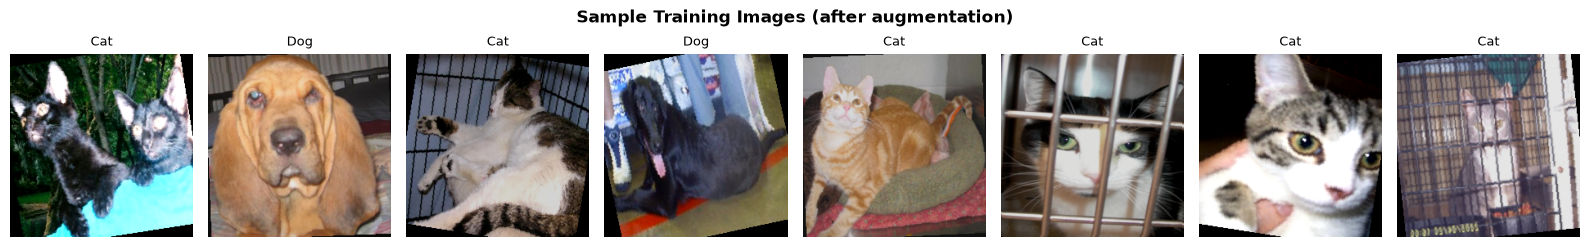

In [6]:
def imshow_grid(loader, n=8):
    imgs, labels = next(iter(loader))
    imgs = imgs[:n]
    labels = labels[:n]

    # Denormalise
    mean = torch.tensor(MEAN).view(3,1,1)
    std  = torch.tensor(STD).view(3,1,1)
    imgs = (imgs * std + mean).clamp(0, 1)

    fig, axes = plt.subplots(1, n, figsize=(2*n, 2.5))
    for ax, img, lbl in zip(axes, imgs, labels):
        ax.imshow(img.permute(1,2,0).numpy())
        ax.set_title(CLASS_NAMES[lbl], fontsize=9)
        ax.axis("off")
    plt.suptitle("Sample Training Images (after augmentation)", fontweight="bold")
    plt.tight_layout()
    plt.savefig("../data/sample_images.png", dpi=100, bbox_inches="tight")
    plt.show()

imshow_grid(train_loader)

## 🧠 Cell 7 — Model Architecture (EfficientNet-B0 + Custom Head)

In [7]:
NUM_CLASSES = 2

# Load EfficientNet-B0 with ImageNet weights
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# ── Freeze ALL feature extractor layers ──────────────────────────────────────
for param in model.parameters():
    param.requires_grad = False

# ── Replace the classifier head ──────────────────────────────────────────────
in_features = model.classifier[1].in_features   # 1280 for EfficientNet-B0

model.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(256, NUM_CLASSES),
)

model = model.to(DEVICE)

# Count trainable vs total parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params     : {total_params:,}")
print(f"Trainable params : {trainable_params:,}  ({100*trainable_params/total_params:.1f}%)")
print(f"\nClassifier head :\n{model.classifier}")

Total params     : 4,335,998
Trainable params : 328,450  (7.6%)

Classifier head :
Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1280, out_features=256, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=256, out_features=2, bias=True)
)


## 🏋️ Cell 8 — Training Utilities

In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, leave=False, desc="  train"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += imgs.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        running_loss += loss.item() * imgs.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += imgs.size(0)
    return running_loss / total, correct / total


print("✅ Utility functions ready.")

✅ Utility functions ready.


## 🚀 Cell 9 — Phase 1: Train Classifier Head (Feature Extractor Frozen)

In [9]:
EPOCHS_PHASE1 = 10
LR_PHASE1     = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_PHASE1)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_PHASE1)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0
CKPT_PATH = "../data/best_model.pth"

print("Phase 1 — Training classifier head only")
print("=" * 55)

for epoch in range(1, EPOCHS_PHASE1 + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    tag = " ← best" if vl_acc > best_val_acc else ""
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), CKPT_PATH)

    print(f"Epoch [{epoch:02d}/{EPOCHS_PHASE1}]  "
          f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f}  │  "
          f"Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}{tag}")

print(f"\n🏆 Best Val Acc (Phase 1): {best_val_acc:.4f}")

Phase 1 — Training classifier head only


  train:   0%|          | 0/547 [00:00<?, ?it/s]

Epoch [01/10]  Train Loss: 0.1703  Acc: 0.9299  │  Val Loss: 0.1007  Acc: 0.9595 ← best


  train:   0%|          | 0/547 [00:00<?, ?it/s]

Epoch [02/10]  Train Loss: 0.1370  Acc: 0.9418  │  Val Loss: 0.0886  Acc: 0.9605 ← best


...

Epoch [08/10]  Train Loss: 0.0998  Acc: 0.9593  │  Val Loss: 0.0683  Acc: 0.9741


  train:   0%|          | 0/547 [00:00<?, ?it/s]

Epoch [09/10]  Train Loss: 0.0993  Acc: 0.9583  │  Val Loss: 0.0704  Acc: 0.9731


  train:   0%|          | 0/547 [00:00<?, ?it/s]

Epoch [10/10]  Train Loss: 0.0941  Acc: 0.9623  │  Val Loss: 0.0720  Acc: 0.9723

🏆 Best Val Acc (Phase 1): 0.9744


## 🔓 Cell 10 — Phase 2: Fine-tuning Top Layers

In [10]:
EPOCHS_PHASE2 = 5
LR_PHASE2     = 1e-4   # much smaller learning rate

# Unfreeze last 2 blocks of EfficientNet features
blocks_to_unfreeze = list(model.features.children())[-2:]
for block in blocks_to_unfreeze:
    for param in block.parameters():
        param.requires_grad = True

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params after unfreeze: {trainable_params:,}")

optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_PHASE2)
scheduler_ft = optim.lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=EPOCHS_PHASE2)

print("\nPhase 2 — Fine-tuning (top backbone layers unlocked)")
print("=" * 55)

for epoch in range(1, EPOCHS_PHASE2 + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer_ft, DEVICE)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion, DEVICE)
    scheduler_ft.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    tag = " ← best" if vl_acc > best_val_acc else ""
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), CKPT_PATH)

    print(f"Epoch [{epoch:02d}/{EPOCHS_PHASE2}]  "
          f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f}  │  "
          f"Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}{tag}")

print(f"\n🏆 Best Val Acc (all phases): {best_val_acc:.4f}")

Trainable params after unfreeze: 1,457,842

Phase 2 — Fine-tuning (top backbone layers unlocked)


  train:   0%|          | 0/547 [00:00<?, ?it/s]

Epoch [01/5]  Train Loss: 0.0917  Acc: 0.9634  │  Val Loss: 0.0497  Acc: 0.9837 ← best


  train:   0%|          | 0/547 [00:00<?, ?it/s]

Epoch [02/5]  Train Loss: 0.0666  Acc: 0.9744  │  Val Loss: 0.0463  Acc: 0.9843 ← best


...

Epoch [03/5]  Train Loss: 0.0579  Acc: 0.9792  │  Val Loss: 0.0436  Acc: 0.9843


  train:   0%|          | 0/547 [00:00<?, ?it/s]

Epoch [04/5]  Train Loss: 0.0495  Acc: 0.9810  │  Val Loss: 0.0392  Acc: 0.9859 ← best


  train:   0%|          | 0/547 [00:00<?, ?it/s]

Epoch [05/5]  Train Loss: 0.0472  Acc: 0.9821  │  Val Loss: 0.0417  Acc: 0.9845

🏆 Best Val Acc (all phases): 0.9859


## 📈 Cell 11 — Training & Validation Curves

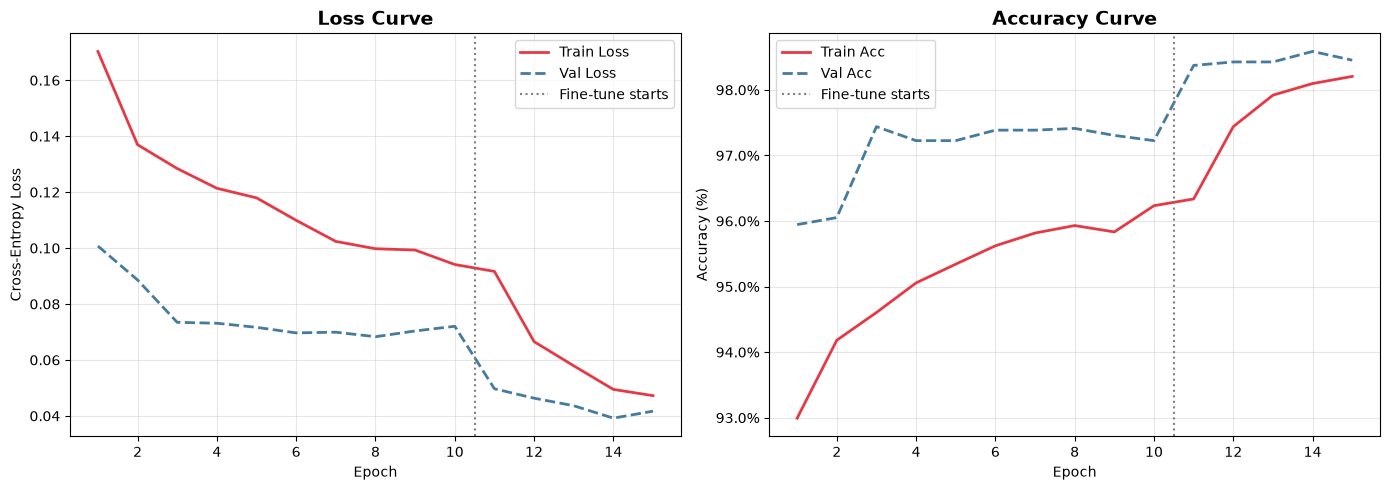

📊 Curves saved to data/training_curves.png


In [11]:
total_epochs = len(history["train_loss"])
epochs_range = range(1, total_epochs + 1)
phase_boundary = EPOCHS_PHASE1 + 0.5   # vertical line between phases

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Loss ─────────────────────────────────────────────────────────────────────
ax1.plot(epochs_range, history["train_loss"], label="Train Loss",  color="#E63946", linewidth=2)
ax1.plot(epochs_range, history["val_loss"],   label="Val Loss",    color="#457B9D", linewidth=2, linestyle="--")
ax1.axvline(x=phase_boundary, color="gray", linestyle=":", label="Fine-tune starts")
ax1.set_title("Loss Curve", fontsize=14, fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── Accuracy ─────────────────────────────────────────────────────────────────
ax2.plot(epochs_range, [a*100 for a in history["train_acc"]], label="Train Acc",  color="#E63946", linewidth=2)
ax2.plot(epochs_range, [a*100 for a in history["val_acc"]],   label="Val Acc",    color="#457B9D", linewidth=2, linestyle="--")
ax2.axvline(x=phase_boundary, color="gray", linestyle=":", label="Fine-tune starts")
ax2.set_title("Accuracy Curve", fontsize=14, fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.yaxis.set_major_formatter(ticker.PercentFormatter())
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../data/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Curves saved to data/training_curves.png")

## 🧪 Cell 12 — Evaluate on Test Set

In [12]:
# Load best checkpoint
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))

test_loss, test_acc = evaluate(model, test_loader, criterion, DEVICE)
print(f"\n{'='*45}")
print(f"  🎯 Test Accuracy : {test_acc*100:.2f}%")
print(f"  📉 Test Loss     : {test_loss:.4f}")
print(f"{'='*45}")


  🎯 Test Accuracy : 98.03%
  📉 Test Loss     : 0.0490


## 🔲 Cell 13 — Confusion Matrix & Classification Report

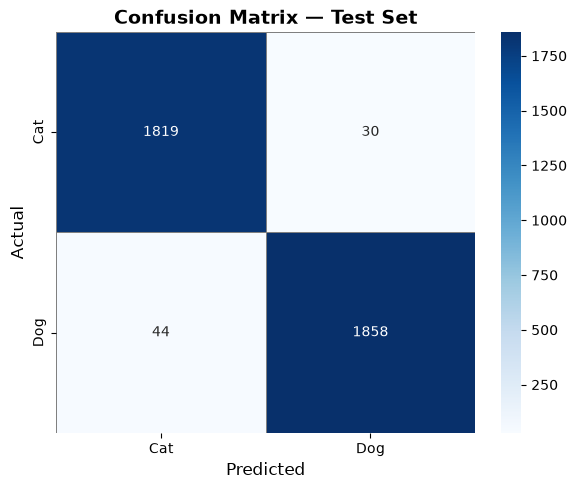


📋 Classification Report:
              precision    recall  f1-score   support

         Cat       0.98      0.98      0.98      1849
         Dog       0.98      0.98      0.98      1902

    accuracy                           0.98      3751
   macro avg       0.98      0.98      0.98      3751
weighted avg       0.98      0.98      0.98      3751



In [13]:
all_preds, all_labels = [], []

model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

cm = confusion_matrix(all_labels, all_preds)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, linecolor="gray", ax=ax
)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual",    fontsize=12)
ax.set_title("Confusion Matrix — Test Set", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📋 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

## 🖼️ Cell 14 — Visual Predictions on Test Images

c:\Users\khale\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


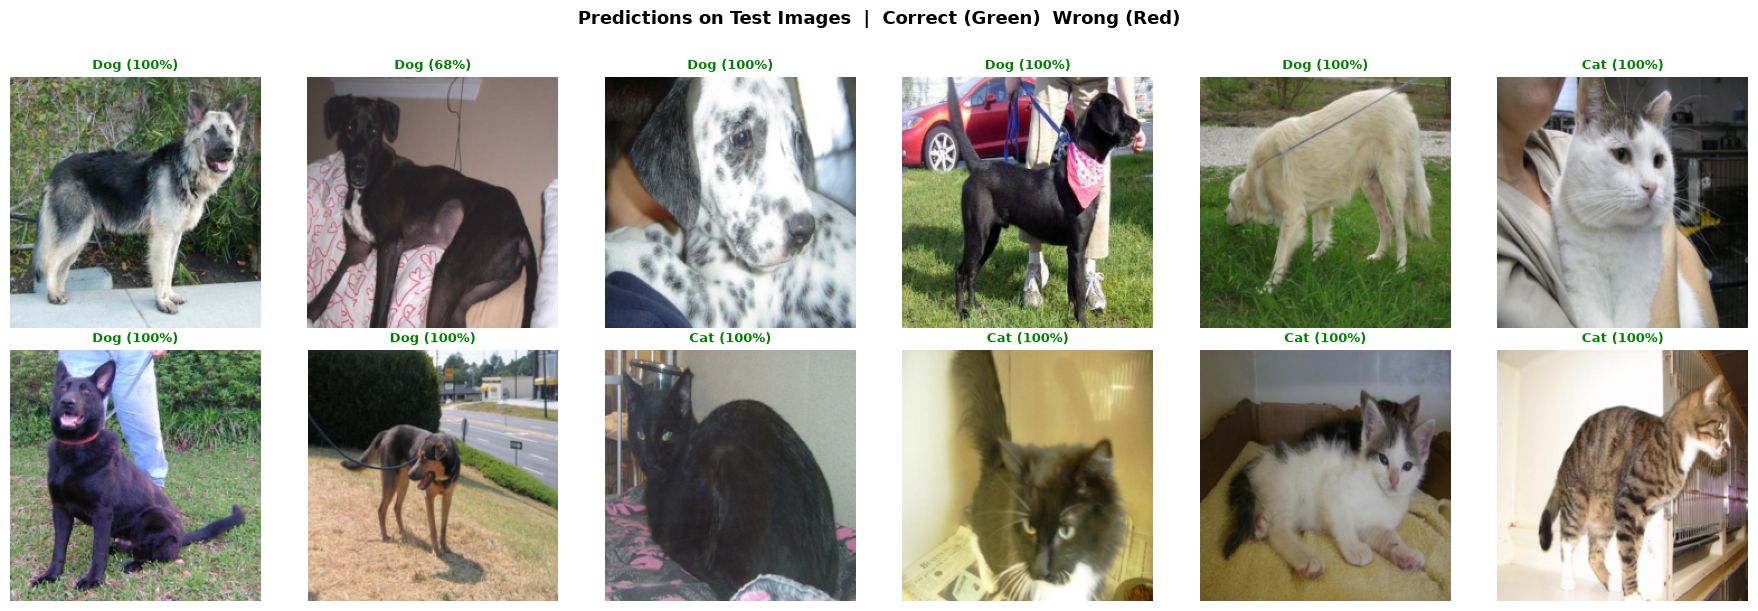

In [14]:
def show_predictions(model, loader, n=12):
    imgs, labels = next(iter(loader))
    imgs_dev = imgs[:n].to(DEVICE)

    model.eval()
    with torch.no_grad():
        probs   = torch.softmax(model(imgs_dev), dim=1)
        preds   = probs.argmax(1).cpu()
        confs   = probs.max(1).values.cpu()

    mean = torch.tensor(MEAN).view(3,1,1)
    std  = torch.tensor(STD).view(3,1,1)
    imgs = (imgs[:n] * std + mean).clamp(0,1)

    cols = 6
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))

    for i, ax in enumerate(axes.flat):
        if i >= n:
            ax.axis("off"); continue
        ax.imshow(imgs[i].permute(1,2,0).numpy())
        correct = preds[i] == labels[i]
        color   = "green" if correct else "red"
        ax.set_title(f"{CLASS_NAMES[preds[i]]} ({confs[i]*100:.0f}%)",
                     color=color, fontsize=9, fontweight="bold")
        ax.axis("off")

    plt.suptitle("Predictions on Test Images  |  Correct (Green)  Wrong (Red)",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig("../data/predictions.png", dpi=120, bbox_inches="tight")
    plt.show()

show_predictions(model, test_loader)

## ✅ Cell 15 — Summary

In [15]:
print("="*55)
print("  PROJECT SUMMARY")
print("="*55)
print(f"  Model          : EfficientNet-B0 (ImageNet pretrained)")
print(f"  Dataset        : Microsoft Cats vs Dogs (~25k images)")
print(f"  Train / Val / Test Split : 70% / 15% / 15%")
print(f"  Phase 1 Epochs : {EPOCHS_PHASE1}  (head only, LR={LR_PHASE1})")
print(f"  Phase 2 Epochs : {EPOCHS_PHASE2}  (fine-tune top blocks, LR={LR_PHASE2})")
print(f"  Best Val Acc   : {best_val_acc*100:.2f}%")
print(f"  Test Accuracy  : {test_acc*100:.2f}%")
print(f"  Test Loss      : {test_loss:.4f}")
print("="*55)
print("  Artifacts saved:")
print("    data/training_curves.png")
print("    data/confusion_matrix.png")
print("    data/predictions.png")
print("    data/best_model.pth")
print("="*55)

  PROJECT SUMMARY
  Model          : EfficientNet-B0 (ImageNet pretrained)
  Dataset        : Microsoft Cats vs Dogs (~25k images)
  Train / Val / Test Split : 70% / 15% / 15%
  Phase 1 Epochs : 10  (head only, LR=0.001)
  Phase 2 Epochs : 5  (fine-tune top blocks, LR=0.0001)
  Best Val Acc   : 98.59%
  Test Accuracy  : 98.03%
  Test Loss      : 0.0490
  Artifacts saved:
    data/training_curves.png
    data/confusion_matrix.png
    data/predictions.png
    data/best_model.pth
